## Time to get your hands dirty. Galaxies vs quasars with neural networks.

Let's go back to our galaxy vs quasar data we've used in a previous exercise. 

1. Read in SDSS galaxy color data from `solutions/galaxyquasar.csv`. Create arrays for the $(u-g)$, $(g-r)$, $(r-i)$, and $(i-z)$ colors. Also create an array with the class labels where galaxy=$0$ and quasar=$1$. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
names = np.genfromtxt('../solutions/galaxyquasar.csv', delimiter=',', names=True, usecols=(0,1,2,3,4,6), dtype=float, comments='#')
names = names.dtype.names
data = np.genfromtxt('../solutions/galaxyquasar.csv', delimiter=',', skip_header=1, usecols=(0,1,2,3,4,6),dtype=float,comments='#')
l = np.genfromtxt('../solutions/galaxyquasar.csv', delimiter=',', skip_header=1, usecols=5, dtype=str)

In [3]:
d = dict(zip(names, data.T))

In [4]:
sub_colors = ['ug', 'gr', 'ri', 'iz']
for n in sub_colors:
    d[n] = d[n[0]] - d[n[1]]

labels = []
for i in range(len(l)):
    if l[i] == 'QSO': 
        labels.append(1)
    else: labels.append(0)

labels = np.array(labels)
d['lab'] = labels


2. Now we're going to fit a neural network classifier. First, scale your data appropriately and do a 30% train/test split.


In [5]:
from sklearn.model_selection import train_test_split

#selecting the columns, scaling and splitting
X = np.column_stack([d[c] for c in sub_colors])
y = d['lab']

X_means = [np.mean(X[:, i]) for i in range(0, 4)]
X_std = [np.std(X[:, i]) for i in range(0, 4)]
X = (X - X_means) / X_std

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

3. Now train the classifier. Use one the package among those we've seen. These include Tensorflow via keras, pytorch, and the MPL classifier implemented in scikit-learn. This is an opportunity to pick the one you're most interested in learning. 

3. Start from a network architecture with a single hidden layer with 5 neurons, using the `adam` solver, the `relu` activation function, and a learninig rate of `0.001`. Plot the resulting ROC curve. 


In [6]:
import tensorflow as tf
from tensorflow import keras

In [7]:
model = keras.models.Sequential([
    keras.layers.InputLayer(input_shape=[len(sub_colors)]),
    keras.layers.Dense(units = 5,  activation='relu'), #5-neuron layer
    keras.layers.Dense(units=1, activation='sigmoid') #final output
])

C:\Users\lm101\anaconda3\envs\astro_env\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 5)                   │              25 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │               6 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    loss = keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam(learning_rate=1e-3), 
    metrics=['accuracy']
)

clf = model.fit(X_train, y_train, epochs=3)

Epoch 1/3
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9283 - loss: 0.3307
Epoch 2/3
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9736 - loss: 0.1362
Epoch 3/3
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9798 - loss: 0.0831


In [10]:
y_pred = model.predict(X_test).ravel()

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 507us/step


In [11]:
from sklearn.metrics import roc_curve

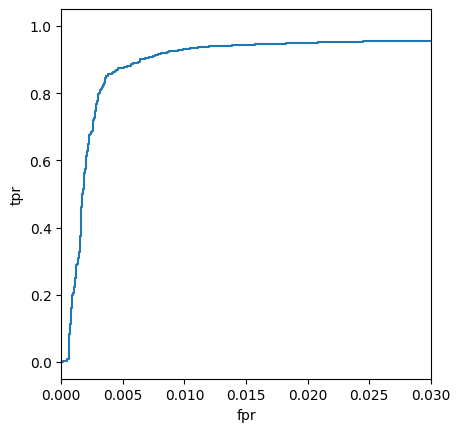

In [12]:
fpr, tpr, threshold = roc_curve(y_true=y_test, y_score=y_pred)

plt.plot(fpr, tpr)
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.xlim(0.0, 0.03)
plt.gca().set_box_aspect(1)
plt.show()


4. Now let's optimize the hyperparameters of your network. Explore different hyperparameters and see what fits the data best.  Do your best now to optimize the network architecture. Be creative!

5. Is your best result comparable with the simpler classifiers we've seen before? Do we need deep learning here? If yes, which features are captured best?


A few tips:

- In scikit-learn, remember that you can utilize all availables cores on your machine with `n_jobs=-1`. Print out the classification score for the training data, and the best parameters obtained by the cross validation.
- If it takes too long, run the hyperparameter optimization on a subset of the training set. Then retrain the full network using the best hyperparameters only.
- On cross validation, for scikit learn we've seen how to use `GridSearchCV` already. For Tensorflow, there's a really cool tool called [Tensorboard](https://www.tensorflow.org/tensorboard)

In [13]:
import keras_tuner as kt

In [14]:
def model_builder(hp):
    #starting with the same input layer
    model = keras.Sequential()
    model.add(keras.layers.InputLayer(shape=[len(sub_colors)]))
    
    #different # of neutrons
    hp_nneurons = hp.Int('neurons', min_value=3, max_value=18, step=3)
    
    #can also try different activation functions
    hp_activation = hp.Choice('activation', values=['relu', 'tanh'])
    
    model.add(keras.layers.Dense(units=hp_nneurons,  activation=hp_activation))
    
    #final output
    model.add(keras.layers.Dense(units=1, activation='sigmoid'))

    #different learning rates
    hp_lr = hp.Choice('learning_rate', values=[1e-4, 1e-3, 1e-2, 1e-1, 0.5])
    model.compile(
            loss = keras.losses.BinaryCrossentropy(),
            optimizer=keras.optimizers.Adam(learning_rate=hp_lr), 
            metrics=['accuracy']
    )
    
    return model

#test if it builds
model_builder(kt.HyperParameters())

<Sequential name=sequential_1, built=True>

In [15]:
tuner = kt.Hyperband(hypermodel=model_builder,
                     objective='val_accuracy',
                     overwrite=False, #put to True to ignore existing saves and retune
                     project_name='qso_nn'
                    )
tuner.search_space_summary()

Search space summary
Default search space size: 3
neurons (Int)
{'default': None, 'conditions': [], 'min_value': 3, 'max_value': 18, 'step': 3, 'sampling': 'linear'}
activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'tanh'], 'ordered': False}
learning_rate (Choice)
{'default': 0.0001, 'conditions': [], 'values': [0.0001, 0.001, 0.01, 0.1, 0.5], 'ordered': True}


In [16]:
X_train.shape, X_test.shape

((35000, 4), (15000, 4))

In [17]:
tuner.search(X_train[:3000], y_train[:3000], epochs=2, validation_data=(X_test[:900], y_test[:900]))

Trial 58 Complete [00h 00m 02s]
val_accuracy: 0.9733333587646484

Best val_accuracy So Far: 0.9833333492279053
Total elapsed time: 00h 01m 35s


In [18]:
best_model = tuner.get_best_models(num_models=1)[0]
best_model.summary()

C:\Users\lm101\anaconda3\envs\astro_env\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 12)                  │              60 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              13 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 73 (292.00 B)

 Trainable params: 73 (292.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
#for all the results:
#tuner.results_summary()

In [20]:
best_hps = tuner.get_best_hyperparameters()
print(best_hps[0].values)

{'neurons': 12, 'activation': 'tanh', 'learning_rate': 0.1, 'tuner/epochs': 2, 'tuner/initial_epoch': 0, 'tuner/bracket': 4, 'tuner/round': 0}


In [34]:
#finally train the best model on the entire X_train
#can afford to have more epochs, even though it's already pretty good after just one
best_model.fit(X_train, y_train, epochs = 3)

Epoch 1/3
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 1s 916us/step - accuracy: 0.9826 - loss: 0.0629
Epoch 2/3
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 1s 800us/step - accuracy: 0.9828 - loss: 0.0629
Epoch 3/3
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 1s 830us/step - accuracy: 0.9825 - loss: 0.0629


In [22]:
y_pred = best_model.predict(X_test).ravel()
fpr, tpr,_=roc_curve(y_test, y_pred)

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 496us/step


In [23]:
#comparing with the best model from W19
from astroML.classification import GMMBayes
clf=GMMBayes(n_components=3)
clf.fit(X_train, y_train)
y_pred= clf.predict_proba(X_test)[:,1]
fpr_gmm, tpr_gmm, _ = roc_curve(y_test, y_pred)

In [25]:
#and with the original model, not hyperturned
y_pred = model.predict(X_test).ravel()
fpr_, tpr_, threshold = roc_curve(y_true=y_test, y_score=y_pred)

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 499us/step


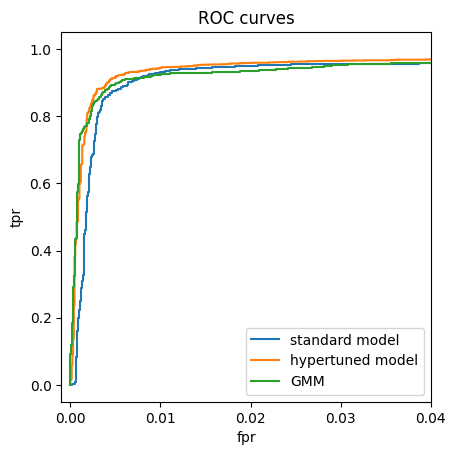

In [26]:
plt.plot(fpr_, tpr_, label='standard model')
plt.plot(fpr, tpr, label='hypertuned model')
plt.plot(fpr_gmm, tpr_gmm, label='GMM')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title('ROC curves')
plt.xlim(-0.001, 0.04)
plt.gca().set_box_aspect(1)
plt.legend()
plt.show()

The GMM modes isn't doing so bad afterall, deep learning is not really needed. The standard model also doesn't perform too badly compared to the hypertuned one.

Finally, just want to try dropout layers even though I don't expect them to be so effective in this case:

In [27]:
def dropout_model_builder(hp):
    #starting with the same input layer
    model = keras.Sequential()
    model.add(keras.layers.InputLayer(shape=[len(sub_colors)]))
    
    #different # of neutrons
    hp_nneurons = hp.Int('neurons', min_value=3, max_value=18, step=3)

    #just keep relu here
    model.add(keras.layers.Dense(units=hp_nneurons,  activation='relu'))

    #rate = fraction of input to drop
    hp_rate=hp.Choice('dropout_rate', values=[0.3, 0.5, 0.7])
    model.add(keras.layers.Dropout(rate=hp_rate))

    #final output
    model.add(keras.layers.Dense(units=1, activation='sigmoid'))

    #different learning rates
    hp_lr = hp.Choice('learning_rate', values=[1e-4, 1e-3, 1e-2, 1e-1, 0.5])
    model.compile(
            loss = keras.losses.BinaryCrossentropy(),
            optimizer=keras.optimizers.Adam(learning_rate=hp_lr), 
            metrics=['accuracy']
    )
    
    return model

#test if it builds
dropout_model_builder(kt.HyperParameters())

<Sequential name=sequential_1, built=True>

In [28]:
do_tuner = kt.Hyperband(hypermodel=dropout_model_builder,
                     objective='val_accuracy',
                     overwrite=False, #put to True to ignore existing saves and retune
                     project_name='qso_nn_dropout'
                    )
do_tuner.search_space_summary()

Search space summary
Default search space size: 3
neurons (Int)
{'default': None, 'conditions': [], 'min_value': 3, 'max_value': 18, 'step': 3, 'sampling': 'linear'}
dropout_rate (Choice)
{'default': 0.3, 'conditions': [], 'values': [0.3, 0.5, 0.7], 'ordered': True}
learning_rate (Choice)
{'default': 0.0001, 'conditions': [], 'values': [0.0001, 0.001, 0.01, 0.1, 0.5], 'ordered': True}


In [29]:
do_tuner.search(X_train[:3000], y_train[:3000], epochs=2, validation_data=(X_test[:900], y_test[:900]))

Trial 82 Complete [00h 00m 02s]
val_accuracy: 0.9800000190734863

Best val_accuracy So Far: 0.9844444394111633
Total elapsed time: 00h 02m 57s


In [30]:
do_model = do_tuner.get_best_models(num_models=1)[0]
do_model.summary()

C:\Users\lm101\anaconda3\envs\astro_env\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 12)                  │              60 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 12)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              13 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 73 (292.00 B)

 Trainable params: 73 (292.00 B)

 Non-trainable params: 0 (0.00 B)

In [31]:
do_model.fit(X_train, y_train, epochs = 3)

Epoch 1/3
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 2s 896us/step - accuracy: 0.9662 - loss: 0.1858
Epoch 2/3
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 1s 836us/step - accuracy: 0.9671 - loss: 0.2066
Epoch 3/3
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 1s 838us/step - accuracy: 0.9669 - loss: 0.1607


In [32]:
y_pred = do_model.predict(X_test).ravel()
fpr_do, tpr_do,_=roc_curve(y_test, y_pred)

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 475us/step


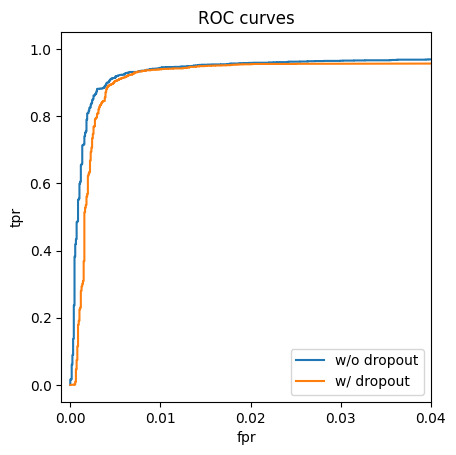

In [33]:
plt.plot(fpr, tpr, label='w/o dropout')
plt.plot(fpr_do, tpr_do, label='w/ dropout')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title('ROC curves')
plt.xlim(-0.001, 0.04)
plt.gca().set_box_aspect(1)
plt.legend()
plt.show()

It doesn't seem to improve our model that much, but it makese sense as it's a fairly simple problem without a lot of features/layers.

In [35]:
best_hps = do_tuner.get_best_hyperparameters()
print(best_hps[0].values)

{'neurons': 12, 'dropout_rate': 0.3, 'learning_rate': 0.1, 'tuner/epochs': 2, 'tuner/initial_epoch': 0, 'tuner/bracket': 4, 'tuner/round': 0}
